In [7]:
import requests
import base64
from io import BytesIO, StringIO
import json
from PIL import Image
import numpy as np
import glob
from IPython.display import display, JSON
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [8]:
SERVER_QUALITY_URL = 'http://localhost:8501/v1/models/quality_model:predict'
SERVER_DETECTION_URL = 'http://localhost:8501/v1/models/detection_model:predict'
SERVER_DEVICE_TYPE_URL = 'http://localhost:8501/v1/models/device_type_model:predict'

DEVICE_TYPES = ['BIO_ICD', 'BIO_PM', 'BSC_CRT-P', 'BSC_ICD', 'BSC_PM', 'BSC_S-ICD', 'ELA_PM', 'IMC_PM', 'MED_CRT-P',
                'MED_ICD', 'MED_ICM', 'MED_PM', 'SJM_CRT-P', 'SJM_ICD', 'SJM_PM', 'TPS_PM', 'VIT_PM']

In [9]:
def send_server_request(server_url, instances, headers):
    predict_request = json.dumps({'instances': instances})
    response = requests.post(server_url, data=predict_request, headers=headers)
    response.raise_for_status()
    return response.json()


def base64_image(img):
    buffered = BytesIO()
    img.save(buffered, format="PNG")
    return base64.b64encode(buffered.getvalue()).decode('utf-8')

def crop_dcm(dataset, box):
    img = dataset.pixel_array
    y1 = int(box[0] * img.shape[1])
    x1 = int(box[1] * img.shape[0])
    y2 = int(box[2] * img.shape[1])
    x2 = int(box[3] * img.shape[0])
    area = (x1, y1, x2, y2)
    img = (img - np.mean(img)) / np.std(img) / 3.0 * 255.0 + 128.0
    return Image.fromarray(img).crop(area).convert('RGB')

def detect_device(images):
  instances = []
  for im in images:
    instances.append({'b64': base64_image(im)})
  result = send_server_request(SERVER_DETECTION_URL, instances, {})
  return result

def predict_device_type(images):
  instances = []
  for im in images:
    instances.append({'b64': base64_image(im)})

  result_quality = send_server_request(SERVER_QUALITY_URL, instances, {})
  image_quality = []
  for one_hot in result_quality['predictions']:
      image_quality.append(np.dot(one_hot, [0, 1, 2, 3, 4]))

  result_device_type = send_server_request(SERVER_DEVICE_TYPE_URL, instances, {})
  device_types = []
  confidence = []
  for one_hot in result_device_type['predictions']:
      device_types.append(DEVICE_TYPES[np.argmax(one_hot, axis=0)])
      confidence.append(max(one_hot))

  return {'device_type': device_types, 'confidence': confidence, 'image_quality': image_quality}

In [10]:
im = Image.open('./sample_data/cied_images/BSC_ICD_D433_Resonate_EL_ICD_DR.png')
im.show()
print(predict_device_type([im]))

Opening in existing browser session.


HTTPError: 404 Client Error: NOT FOUND for url: http://localhost:8501/v1/models/quality_model:predict

In [5]:
for image_path in glob.glob('./sample_data/cied_images/*.png'):
  im = Image.open(image_path)
  print(image_path)
  print(predict_device_type([im]))




./sample_data/cied_images/BSC_ICD_D433_Resonate_EL_ICD_DR.png
{'device_type': ['BSC_ICD'], 'confidence': [1.0], 'image_quality': [np.float64(3.999480959330203)]}
./sample_data/cied_images/BSC_PM_S501_Altrua_50.png
{'device_type': ['BSC_PM'], 'confidence': [0.999999881], 'image_quality': [np.float64(4.000000117651695)]}
./sample_data/cied_images/MED_CRT-D_D354TRM_Protecta_XT_CRT-D.png
{'device_type': ['MED_ICD'], 'confidence': [1.0], 'image_quality': [np.float64(3.999815679737497)]}


[[0.398935348, 0.700880349, 0.606018424, 0.91875571],
 [0.00388972461, 0.04849343, 0.183900014, 0.220945016],
 [0.00512725115, 0.0245556161, 0.213309139, 0.152014643]]

[0.9998312, 0.997652829, 0.000786694931]

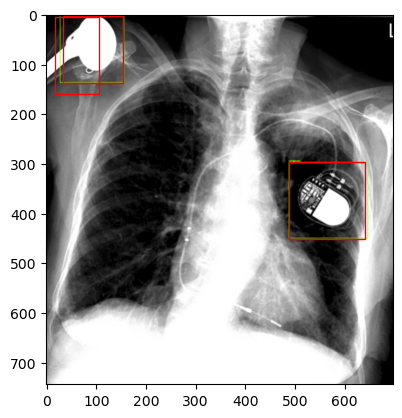

[[0.488791, 0.0618796423, 0.764797926, 0.248811156],
 [0.452125907, 0.540448606, 0.699744463, 0.755753219],
 [0.36413753, 0.755174458, 0.571133912, 0.870423853]]

[0.999857306, 0.99983716, 0.994948626]

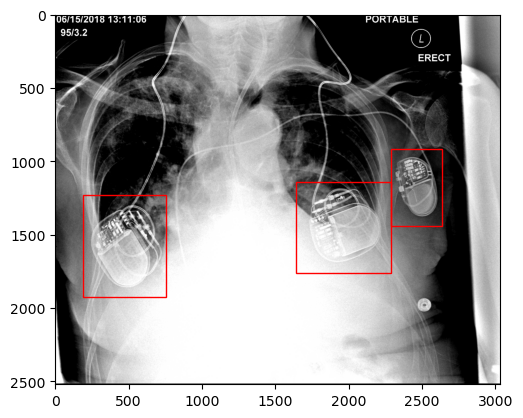

[[0.22615324, 0.0370076746, 0.507397354, 0.22831215],
 [0.312174678, 0.6099931, 0.546931863, 0.766583085],
 [0.875985, 0.536708355, 0.998034835, 0.859213]]

[0.999900222, 0.999784529, 0.000405407365]

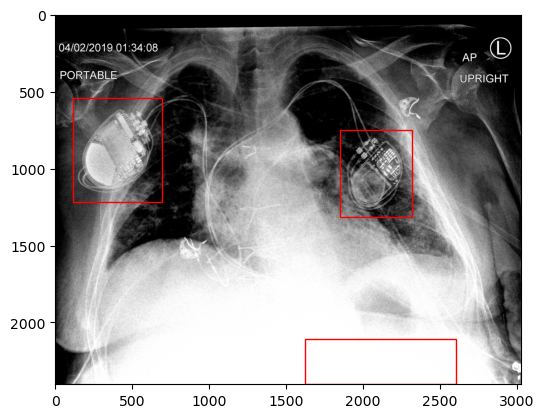

[[0.276291758, 0.649035692, 0.597300053, 0.853006601],
 [0.203871563, 0.179274768, 0.374926209, 0.331670374],
 [0.848974347, 0.0919482186, 0.98842597, 0.304981411]]

[0.999929428, 0.999366224, 0.000816430722]

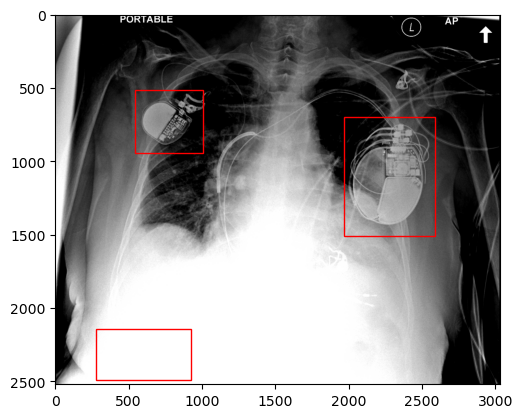

[[0.268739164, 0.110178292, 0.504333854, 0.290572017],
 [0.274732888, 0.627795935, 0.47261256, 0.77090466],
 [0.866361499, 0.186397031, 0.991489172, 0.465301096]]

[0.999734819, 0.999705851, 0.00170661486]

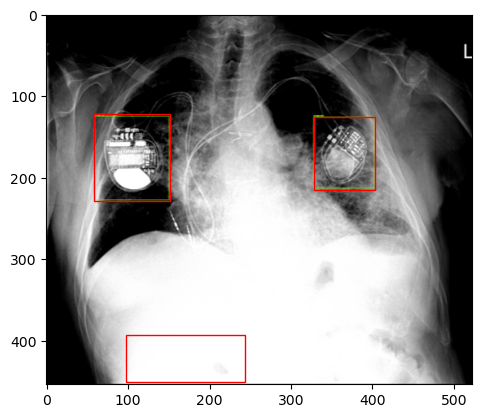

[[0.445937574, 0.589770913, 0.684497178, 0.807514429],
 [0.475432664, 0.0658984855, 0.757286787, 0.262408167],
 [0.342297286, 0.80869472, 0.559563696, 0.9342103]]

[0.999844432, 0.999829531, 0.997804463]

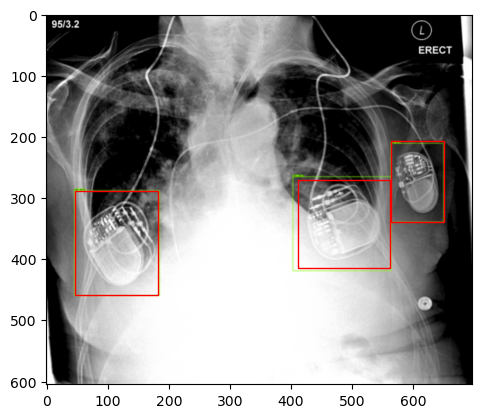

[[0.335964948, 0.163039088, 0.474580258, 0.311546862],
 [0.389171749, 0.671084583, 0.592964768, 0.788412631],
 [0.364707202, 0.638050795, 0.580372691, 0.822018385]]

[0.998929679, 0.986305, 0.00129112939]

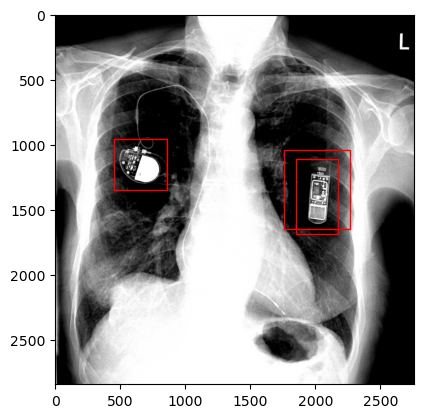

In [6]:

def plot_detection(im_cxr, detection_result):
  detection_result  = detect_device([im_cxr])
  detection_scores = detection_result['predictions'][0]['detection_scores']
  detection_boxes = detection_result['predictions'][0]['detection_boxes']

  display(detection_boxes)
  display(detection_scores)

  # Create figure and axes
  fig, ax = plt.subplots()
  ax.set_aspect('equal', adjustable='box')
  # Display the image
  ax.imshow(im_cxr)

  # Create a Rectangle patch
  for i in range(len(detection_boxes)):
    box = detection_boxes[i]
    # scale to image size
    box[0] = (box[0]) * im_cxr.height
    box[1] = (box[1]) * im_cxr.width
    box[2] = (box[2]) * im_cxr.height
    box[3] = (box[3]) * im_cxr.width
    rect = patches.Rectangle((box[1], box[0]), box[3]-box[1], box[2]-box[0], linewidth=1, edgecolor='r', facecolor='none')
    ax.add_patch(rect)
    

  plt.show()


for im in glob.glob('./sample_data/cxr/*.png'):
  plot_detection(Image.open(im), detect_device([Image.open(im)]))
